DESARROLLO DEL JUEGO:
-	Mínimo-máximo jugadores
-	Edad media 
-	Categorías y mecánicas: Basado en frecuencia, interés medio (wishing y owned) para no sesgar el análisis en base solo a las mejores valoraciones.
-	Diseñadores, artistas y publishers


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [3]:
pwd = %pwd
print(pwd)
bgg_games = pd.read_csv('../data/source/bgg_games.csv')

d:\Usuarios\Emilio\Documentos\GitHub\Tabletop_EDA\Tabletop-games-EDA\src\notebooks


In [4]:
# Estudio de cardinalidad de las variables
cardinalidad = bgg_games.nunique()/len(bgg_games)*100
print("Cardinalidad de cada variable:")
print(cardinalidad)
# Estudio de valores nulos
valores_nulos = bgg_games.isnull().sum()
print("\nValores nulos en cada variable:")
print(valores_nulos)

Cardinalidad de cada variable:
row_id                 100.000000
type                     0.003513
name                    98.127328
min_players              0.035135
max_players              0.098377
playingtime              0.354859
minimum_age              0.070269
release_year             0.678097
average_rating          92.727145
num_of_ratings          13.695454
weight                  16.393788
num_of_weights           3.060221
bayes_average           65.069215
std_deviation           85.788068
language_dependency      0.021081
owned                   19.071042
trading                  2.417258
wanting                  2.557796
wishing                  8.049329
rank_boardgame          98.088680
dtype: float64

Valores nulos en cada variable:
row_id                 0
type                   0
name                   0
min_players            0
max_players            0
playingtime            0
minimum_age            0
release_year           0
average_rating         0
num_of_ratings  

In [5]:
# Estudio de distribuciones en bgg_games
numeric_cols_lcg = bgg_games.select_dtypes(include=[np.number]).columns
categorical_cols_lcg = bgg_games.select_dtypes(exclude=[np.number]).columns
cardinalidad_categoricas = bgg_games[categorical_cols_lcg].nunique()/len(bgg_games)*100
print("\nCardinalidad de variables categóricas:")  
print(cardinalidad_categoricas)
categorical_cols_lcg = categorical_cols_lcg[cardinalidad_categoricas < 10]


Cardinalidad de variables categóricas:
type                    0.003513
name                   98.127328
language_dependency     0.021081
rank_boardgame         98.088680
dtype: float64


In [6]:
tabla_numerica = bgg_games[numeric_cols_lcg]
df_analysis = tabla_numerica.loc[:, ['min_players', 'max_players', 'playingtime', 'minimum_age', 'weight']]

In [7]:
# Cálculo de moda, media y mediana de las variables numéricas
print("Estadísticas descriptivas de variables numéricas:\n")
bgg_games[numeric_cols_lcg].describe()

Estadísticas descriptivas de variables numéricas:



,row_id,min_players,max_players,playingtime,minimum_age,release_year,average_rating,num_of_ratings,weight,num_of_weights,bayes_average,std_deviation,owned,trading,wanting,wishing
count,28462.000000,28462.000000,28462.000000,28462.000000,28462.000000,28462.000000,28462.000000,28462.000000,28462.000000,28462.000000,28462.000000,28462.000000,28462.000000,28462.000000,28462.000000,28462.000000
mean,177632.565385,1.939779,4.701532,75.265617,9.836800,1996.626941,6.519989,1024.217448,1.981291,49.361605,5.681174,1.530819,1869.739302,44.408299,39.878575,291.011700
std,143246.909508,0.692605,2.549365,102.592702,3.506317,170.269323,0.911126,4461.979671,0.782631,211.981069,0.356785,0.295675,6988.476176,108.758654,106.427457,1003.996101
min,1.000000,0.000000,0.000000,1.000000,0.000000,-3500.000000,1.177420,31.000000,1.000000,1.000000,3.689310,0.440836,2.000000,0.000000,0.000000,0.000000
25%,24025.750000,2.000000,4.000000,30.000000,8.000000,2005.000000,5.958723,63.000000,1.333300,4.000000,5.511050,1.330285,170.000000,5.000000,3.000000,19.000000
50%,172084.500000,2.000000,4.000000,45.000000,10.000000,2015.000000,6.550120,143.000000,1.926900,9.000000,5.543060,1.486255,382.000000,13.000000,9.000000,52.000000
75%,298618.750000,2.000000,6.000000,90.000000,12.000000,2020.000000,7.126600,467.000000,2.500000,25.000000,5.669120,1.676635,1124.000000,38.000000,29.000000,167.000000
max,464922.000000,9.000000,30.000000,1200.000000,21.000000,2026.000000,9.843750,142100.000000,4.817000,8634.000000,8.476900,4.182860,239917.000000,3351.000000,1977.000000,27010.000000


In [8]:
print("\n\nMedia de variables numéricas:")
media_bgg = df_analysis.mean()
moda_bgg = df_analysis.mode().loc[0]
mediana_bgg = df_analysis.median()
# creamos una unica tabla para mostrar media, moda y mediana
estadisticas_bgg = pd.DataFrame({'Media': media_bgg, 'Moda': moda_bgg, 'Mediana': mediana_bgg})
print(estadisticas_bgg)



Media de variables numéricas:
                 Media  Moda  Mediana
min_players   1.939779   2.0   2.0000
max_players   4.701532   4.0   4.0000
playingtime  75.265617  30.0  45.0000
minimum_age   9.836800   8.0  10.0000
weight        1.981291   1.0   1.9269


Asimetría (skewness) de las variables numéricas:
num_of_weights    16.039570
release_year     -13.693060
num_of_ratings    13.468109
owned             13.468038
wishing           10.286916
trading            8.534718
wanting            6.918870
playingtime        5.328681
bayes_average      2.993406
max_players        2.705132
std_deviation      1.534833
min_players        1.322722
minimum_age       -0.765901
weight             0.691191
average_rating    -0.330817
row_id             0.236989


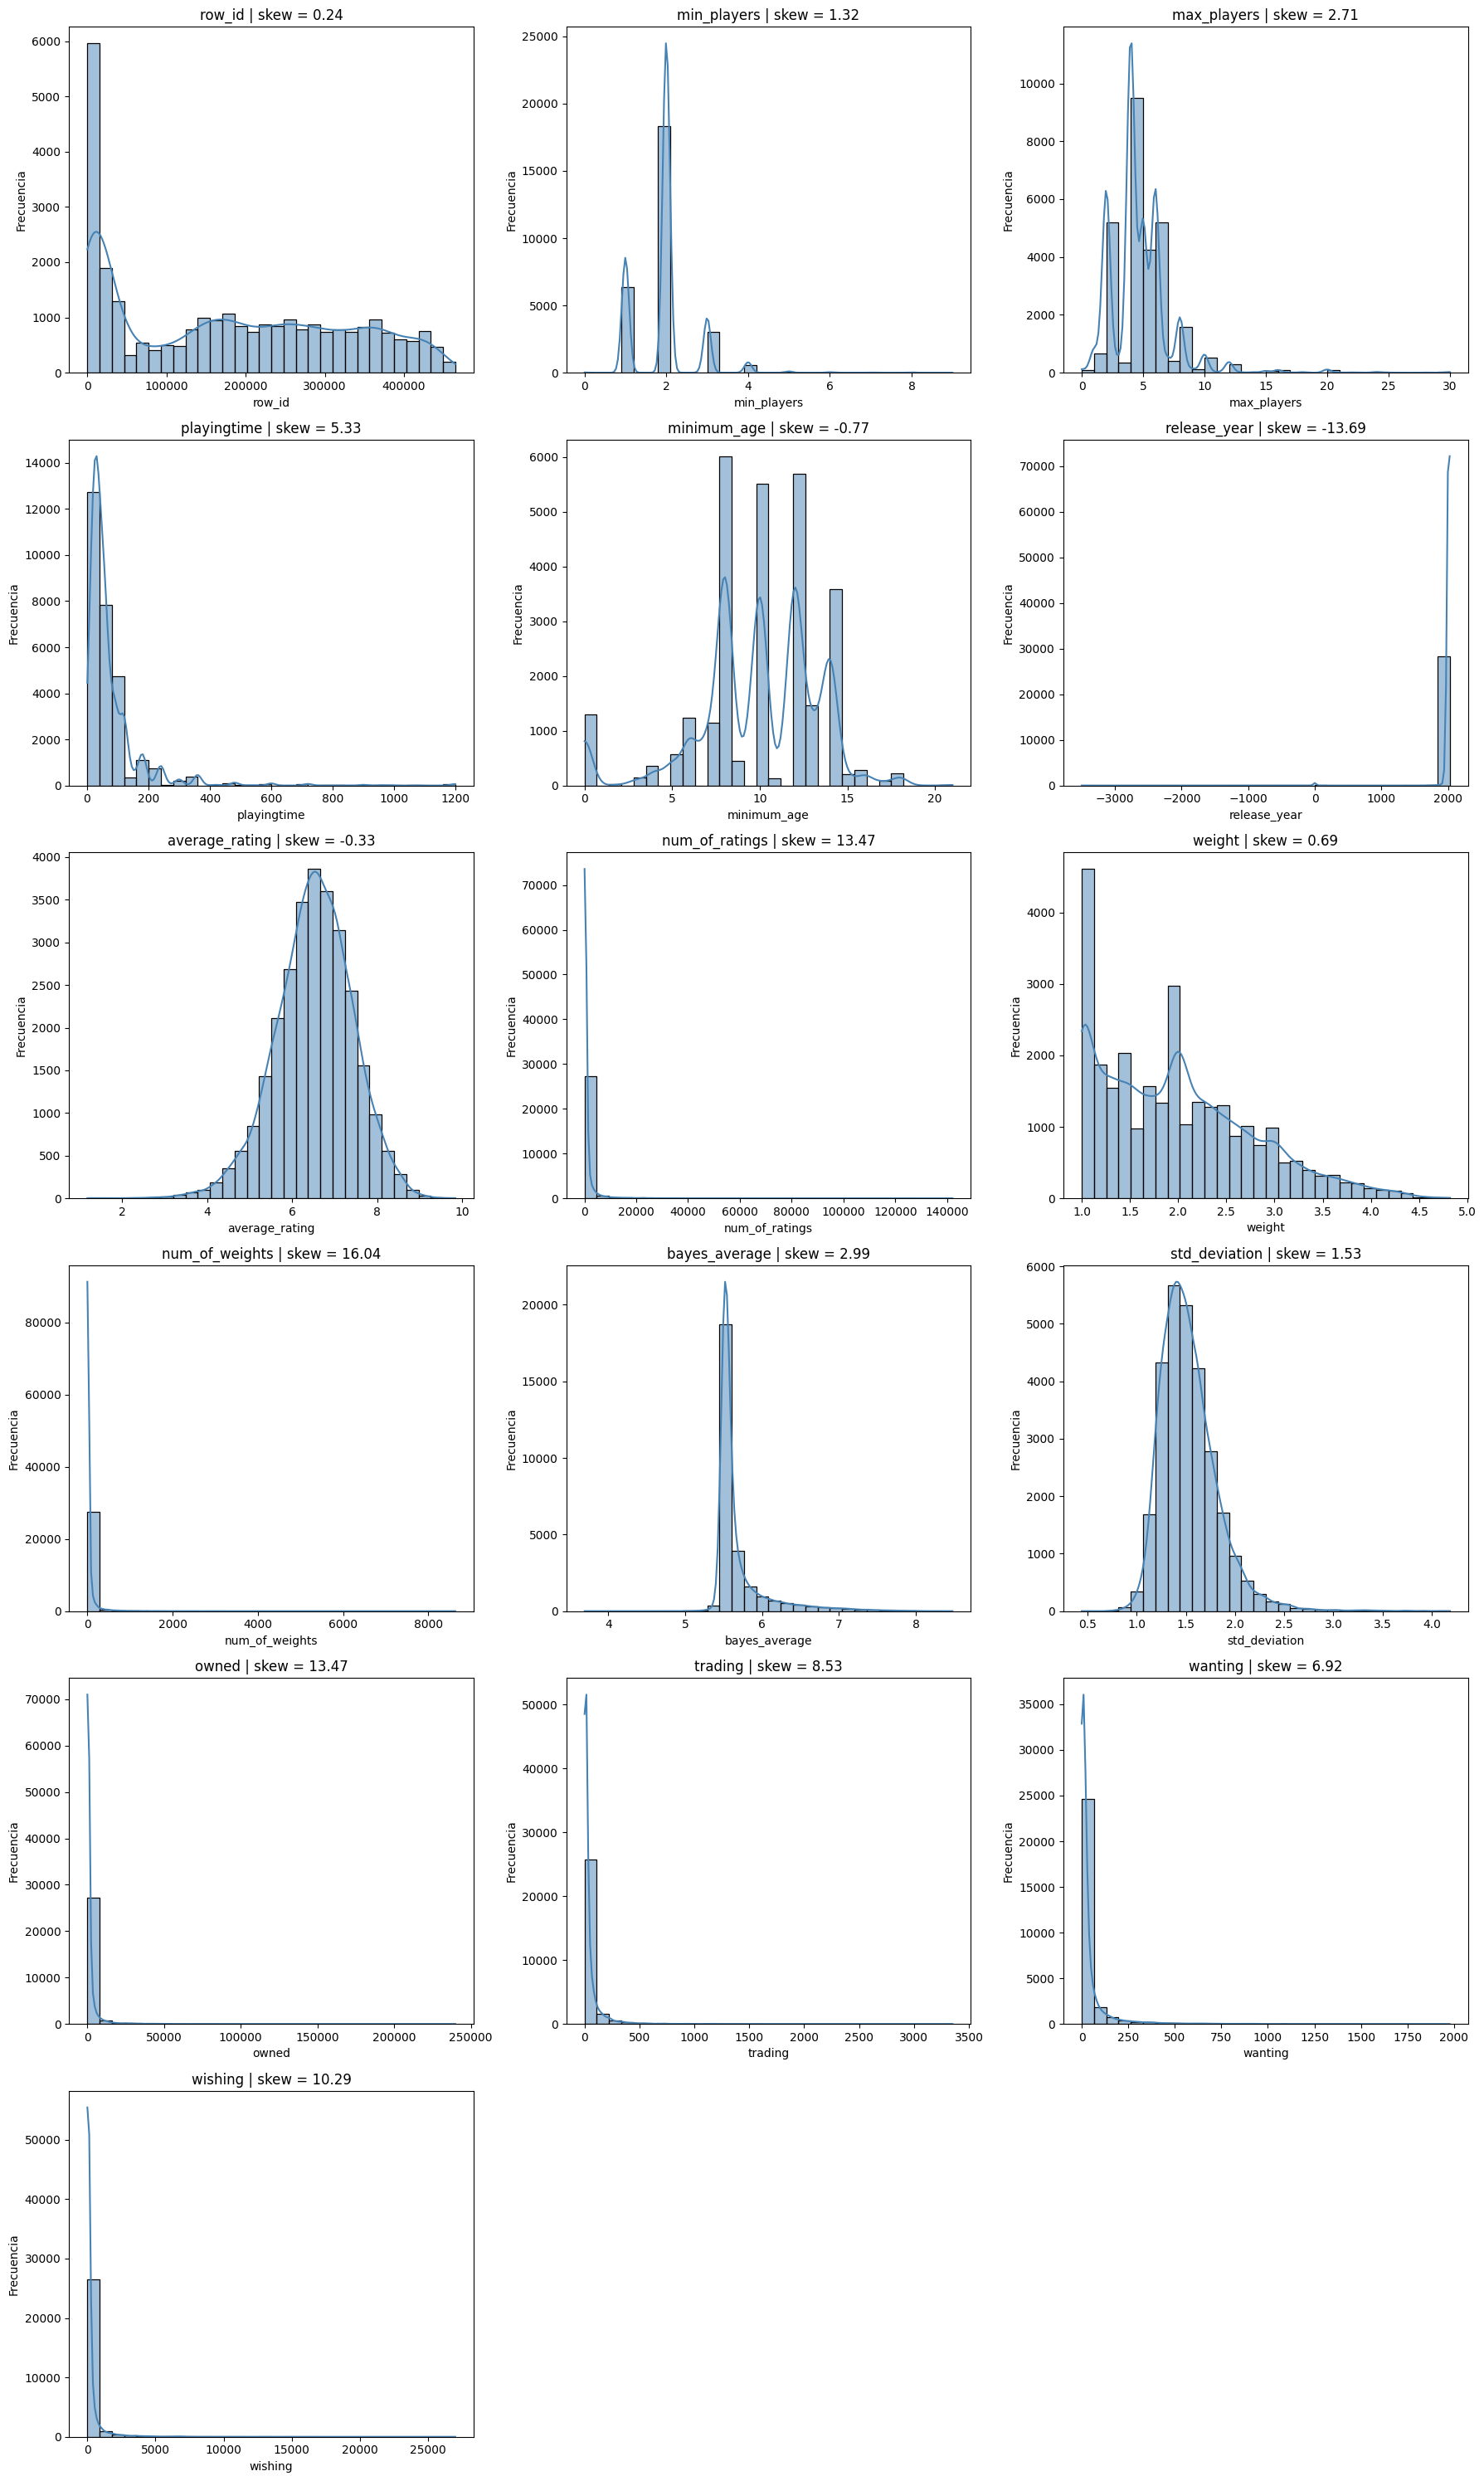

In [9]:
# Resumen de asimetría
skewness = bgg_games[numeric_cols_lcg].skew().sort_values(key=np.abs, ascending=False)
print("Asimetría (skewness) de las variables numéricas:")
print(skewness.to_string())

# Distribuciones numéricas: histograma + KDE
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols_lcg) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = np.ravel(axes)

for i, col in enumerate(numeric_cols_lcg):
    s = bgg_games[col].dropna()
    sk = s.skew()

    sns.histplot(s, kde=True, bins=30, ax=axes[i], color="steelblue")
    axes[i].set_title(f"{col} | skew = {sk:.2f}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

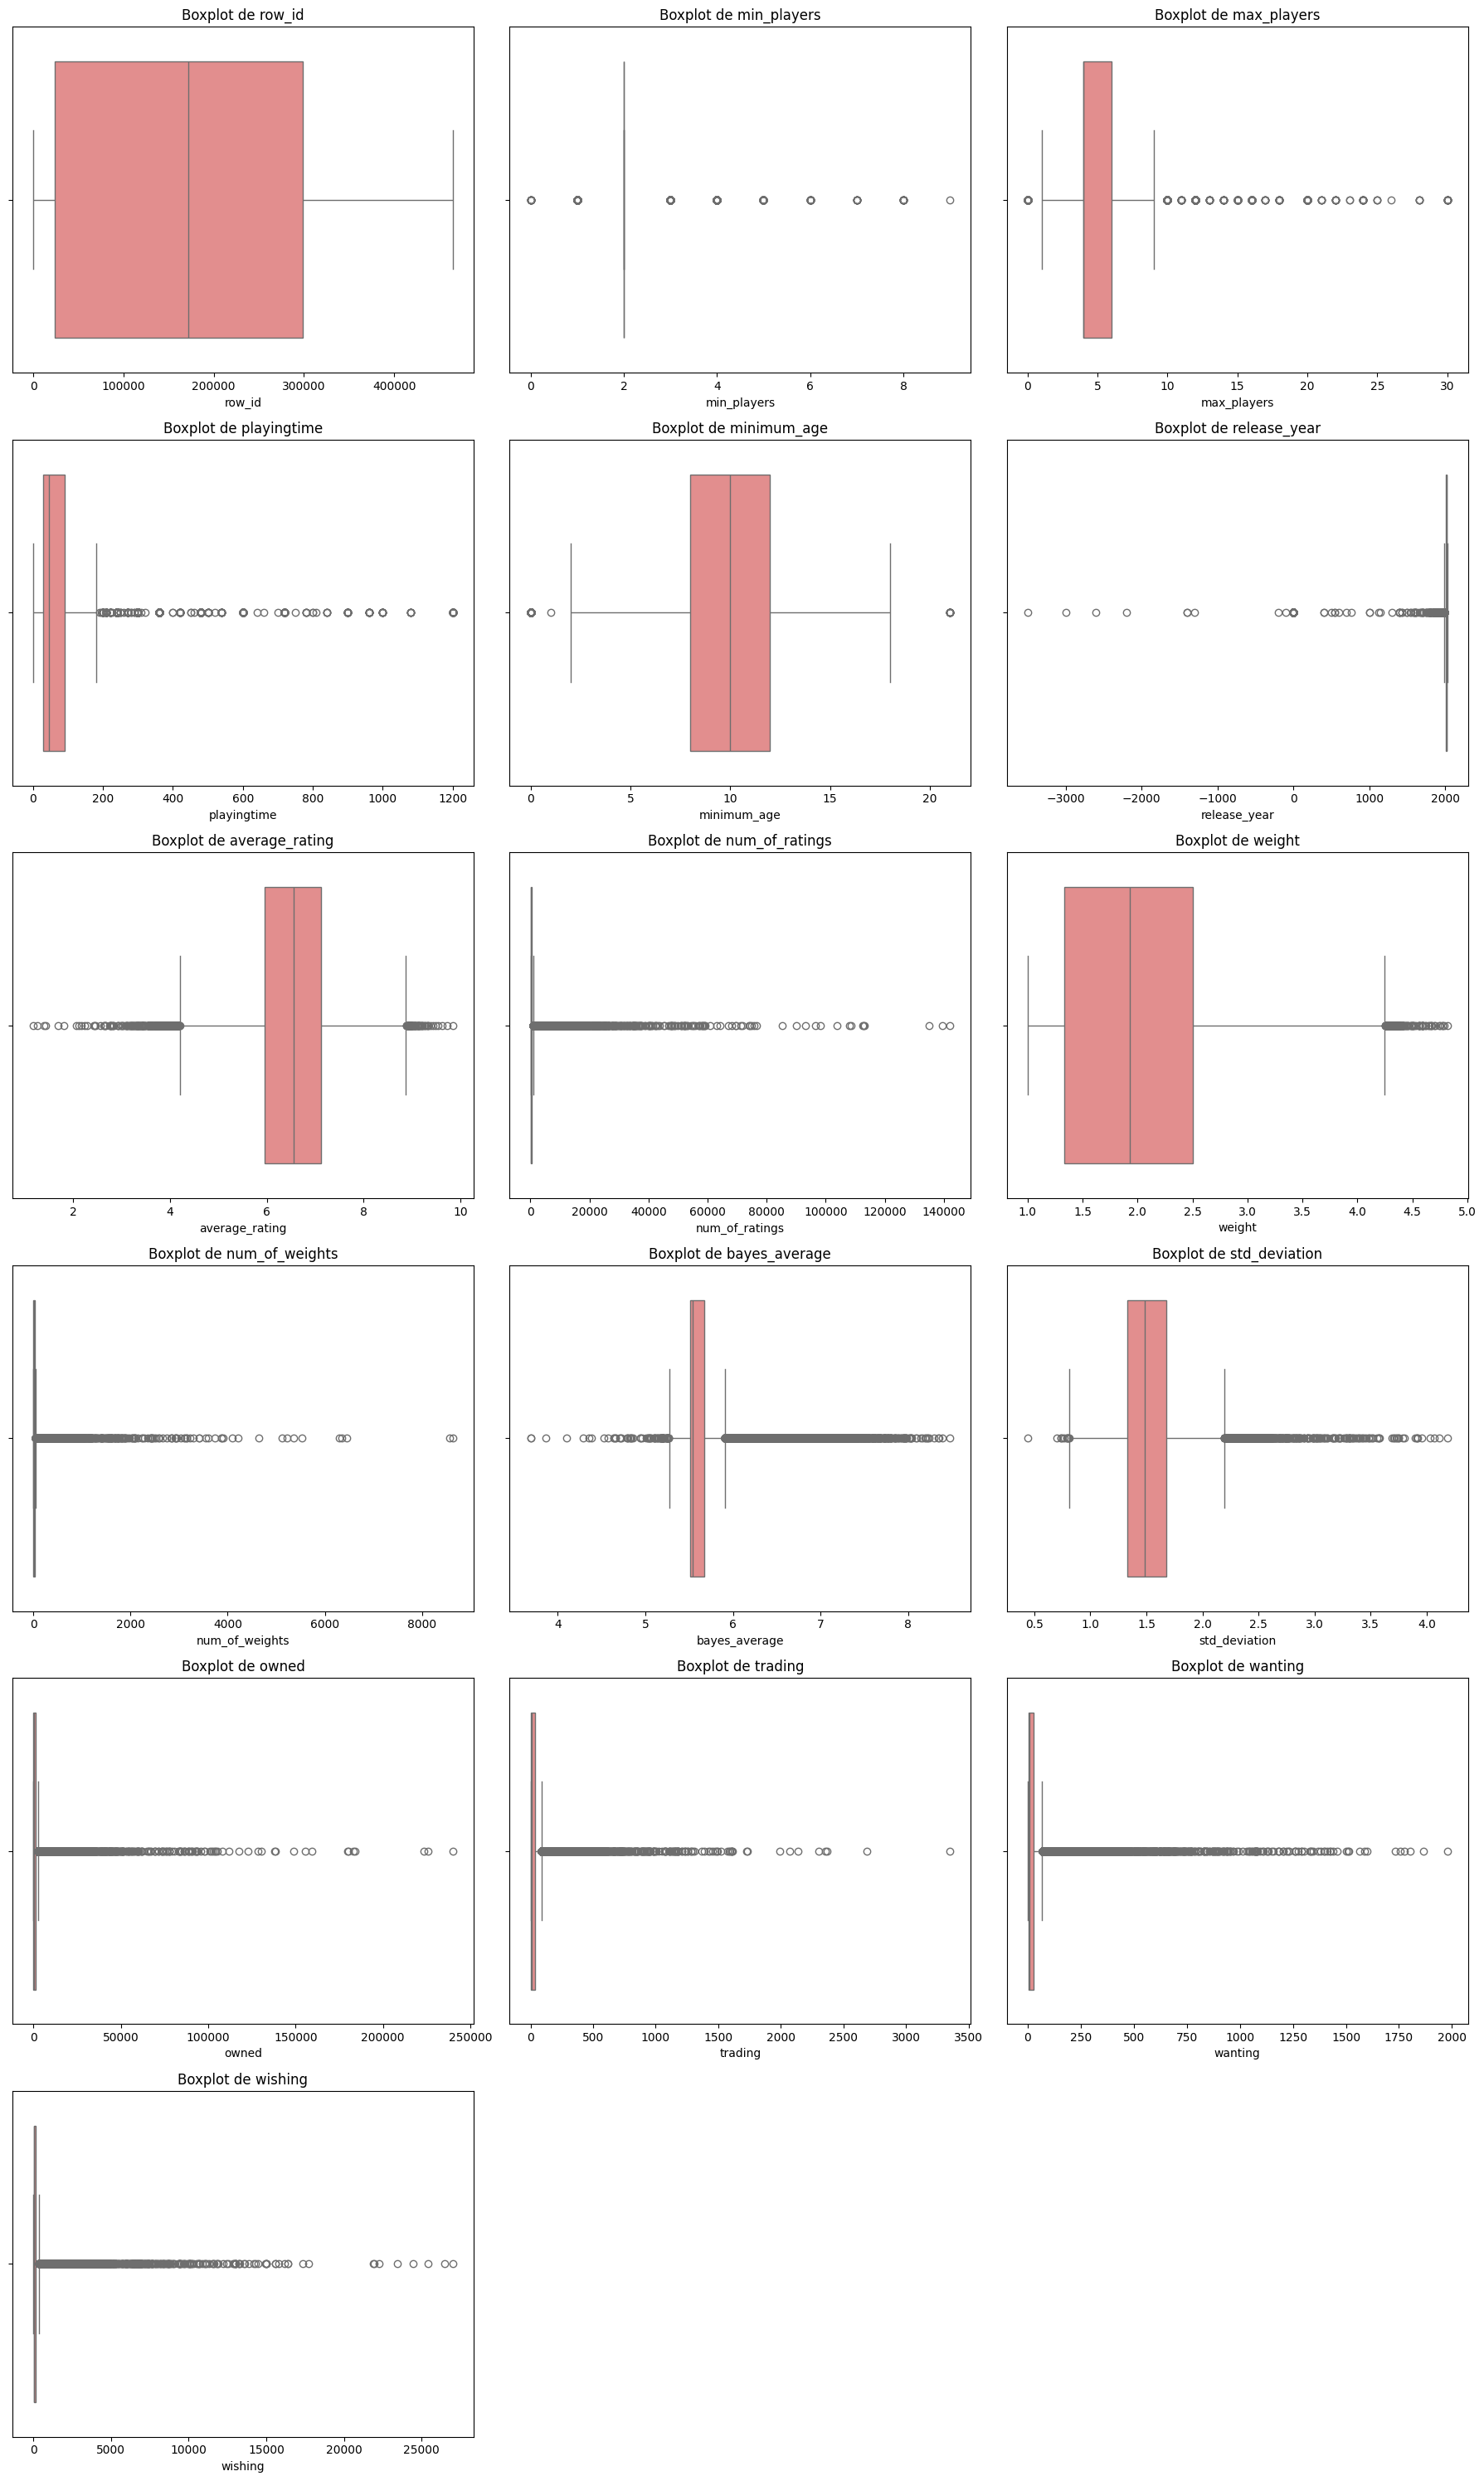

In [10]:
# Boxplots para detectar outliers
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = np.ravel(axes)

for i, col in enumerate(numeric_cols_lcg):
    sns.boxplot(x=bgg_games[col], ax=axes[i], color="lightcoral")
    axes[i].set_title(f"Boxplot de {col}")
    axes[i].set_xlabel(col)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


C:\Users\emili\AppData\Local\Temp\ipykernel_26968\2377649329.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=bgg_games, y=col, order=order, ax=ax, palette="viridis")
C:\Users\emili\AppData\Local\Temp\ipykernel_26968\2377649329.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=bgg_games, y=col, order=order, ax=ax, palette="viridis")


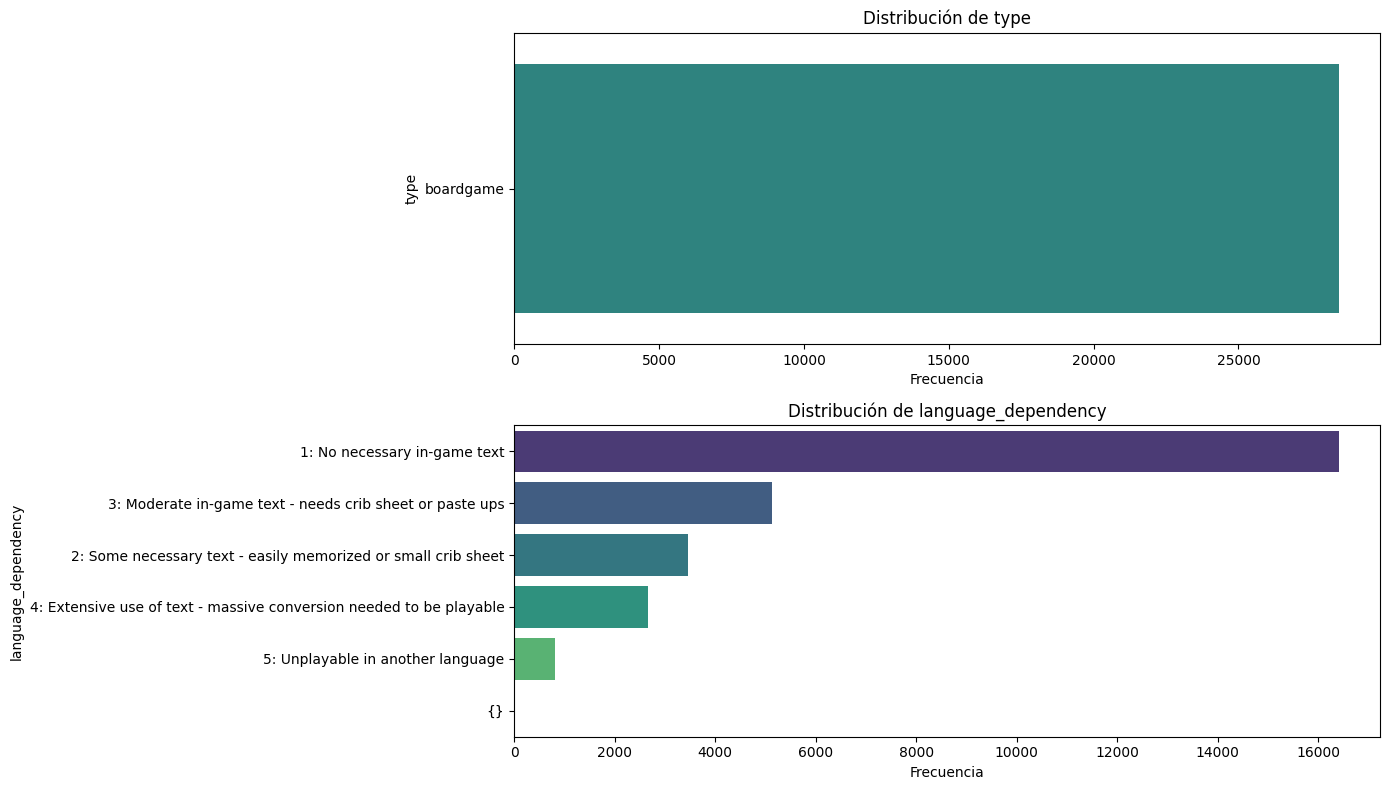

In [11]:

# Variables categóricas: countplot
if len(categorical_cols_lcg) > 0:
    fig, axes = plt.subplots(len(categorical_cols_lcg), 1, figsize=(14, 4 * len(categorical_cols_lcg)))
    if len(categorical_cols_lcg) == 1:
        axes = [axes]

    for ax, col in zip(axes, categorical_cols_lcg):
        order = bgg_games[col].value_counts().index
        sns.countplot(data=bgg_games, y=col, order=order, ax=ax, palette="viridis")
        ax.set_title(f"Distribución de {col}")
        ax.set_xlabel("Frecuencia")
        ax.set_ylabel(col)

    plt.tight_layout()
    plt.show()

In [12]:
artistas = pd.read_csv('../data/source/game_artists.csv')
disenyadores = pd.read_csv('../data/source/game_designers.csv')
categorias = pd.read_csv('../data/source/game_categories.csv')
mecanicas = pd.read_csv('../data/source/game_mechanics.csv')


In [13]:
artistas.head()
disenyadores.head()
categorias.head()
mecanicas.head()

,row_id,mechanisms
0,224517,Chaining
1,224517,End Game Bonuses
2,224517,Hand Management
3,224517,Income
4,224517,Loans


In [14]:
artistas['artists'].value_counts().head(10)
disenyadores['designers'].value_counts().head(10)
categorias['categories'].value_counts().head(10)
mecanicas['mechanisms'].value_counts().head(10)

artistas = artistas[artistas['artists']!= '(Uncredited)']
disenyadores = disenyadores[disenyadores['designers']!= '(Uncredited)']


In [15]:
bgg_games

,row_id,type,name,min_players,max_players,playingtime,minimum_age,release_year,average_rating,num_of_ratings,weight,num_of_weights,bayes_average,std_deviation,language_dependency,owned,trading,wanting,wishing,rank_boardgame
0,224517,boardgame,Brass: Birmingham,2,4,120,14,2018,8.56433,58318,3.8607,2850,8.39353,1.42790,1: No necessary in-game text,83744,367,1754,21874,1
1,187645,boardgame,Star Wars: Rebellion,2,4,240,14,2016,8.42185,36332,3.7535,1278,8.16701,1.36219,4: Extensive use of text - massive conversion ...,57374,393,1460,14975,10
2,201808,boardgame,Clank!: A Deck-Building Adventure,2,4,60,12,2016,7.76073,47406,2.2321,1090,7.59547,1.20797,3: Moderate in-game text - needs crib sheet or...,62182,615,1127,12544,100
3,56692,boardgame,Parade,2,6,45,8,2007,6.99327,8616,1.4571,315,6.65288,1.21890,1: No necessary in-game text,12831,170,294,1805,1000
4,5235,boardgame,Samurai Blades: The Game of Man-to-Man Combat ...,2,6,240,14,1984,6.80140,179,2.3333,15,5.58889,1.35319,1: No necessary in-game text,545,20,21,47,10000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28457,145549,boardgame,Islands of the Damned: Wake Island and Peleliu,1,1,180,14,2015,7.40412,85,2.1176,17,5.56697,1.35851,2: Some necessary text - easily memorized or s...,408,10,25,92,Not Ranked
28458,145535,boardgame,Munchkin Special Holiday Edition,3,6,90,10,2009,5.91429,35,1.0000,1,5.50504,1.64284,1: No necessary in-game text,146,5,8,35,Not Ranked
28459,151377,boardgame,Thurn und Taxis Big Box,2,4,60,13,2008,7.13832,107,2.2000,5,5.56675,1.25874,1: No necessary in-game text,277,10,36,82,Not Ranked
28460,149707,boardgame,Glück Auf (Limited Edition),2,4,75,10,2013,7.26842,38,3.0000,1,5.52549,1.43913,1: No necessary in-game text,148,5,31,56,Not Ranked


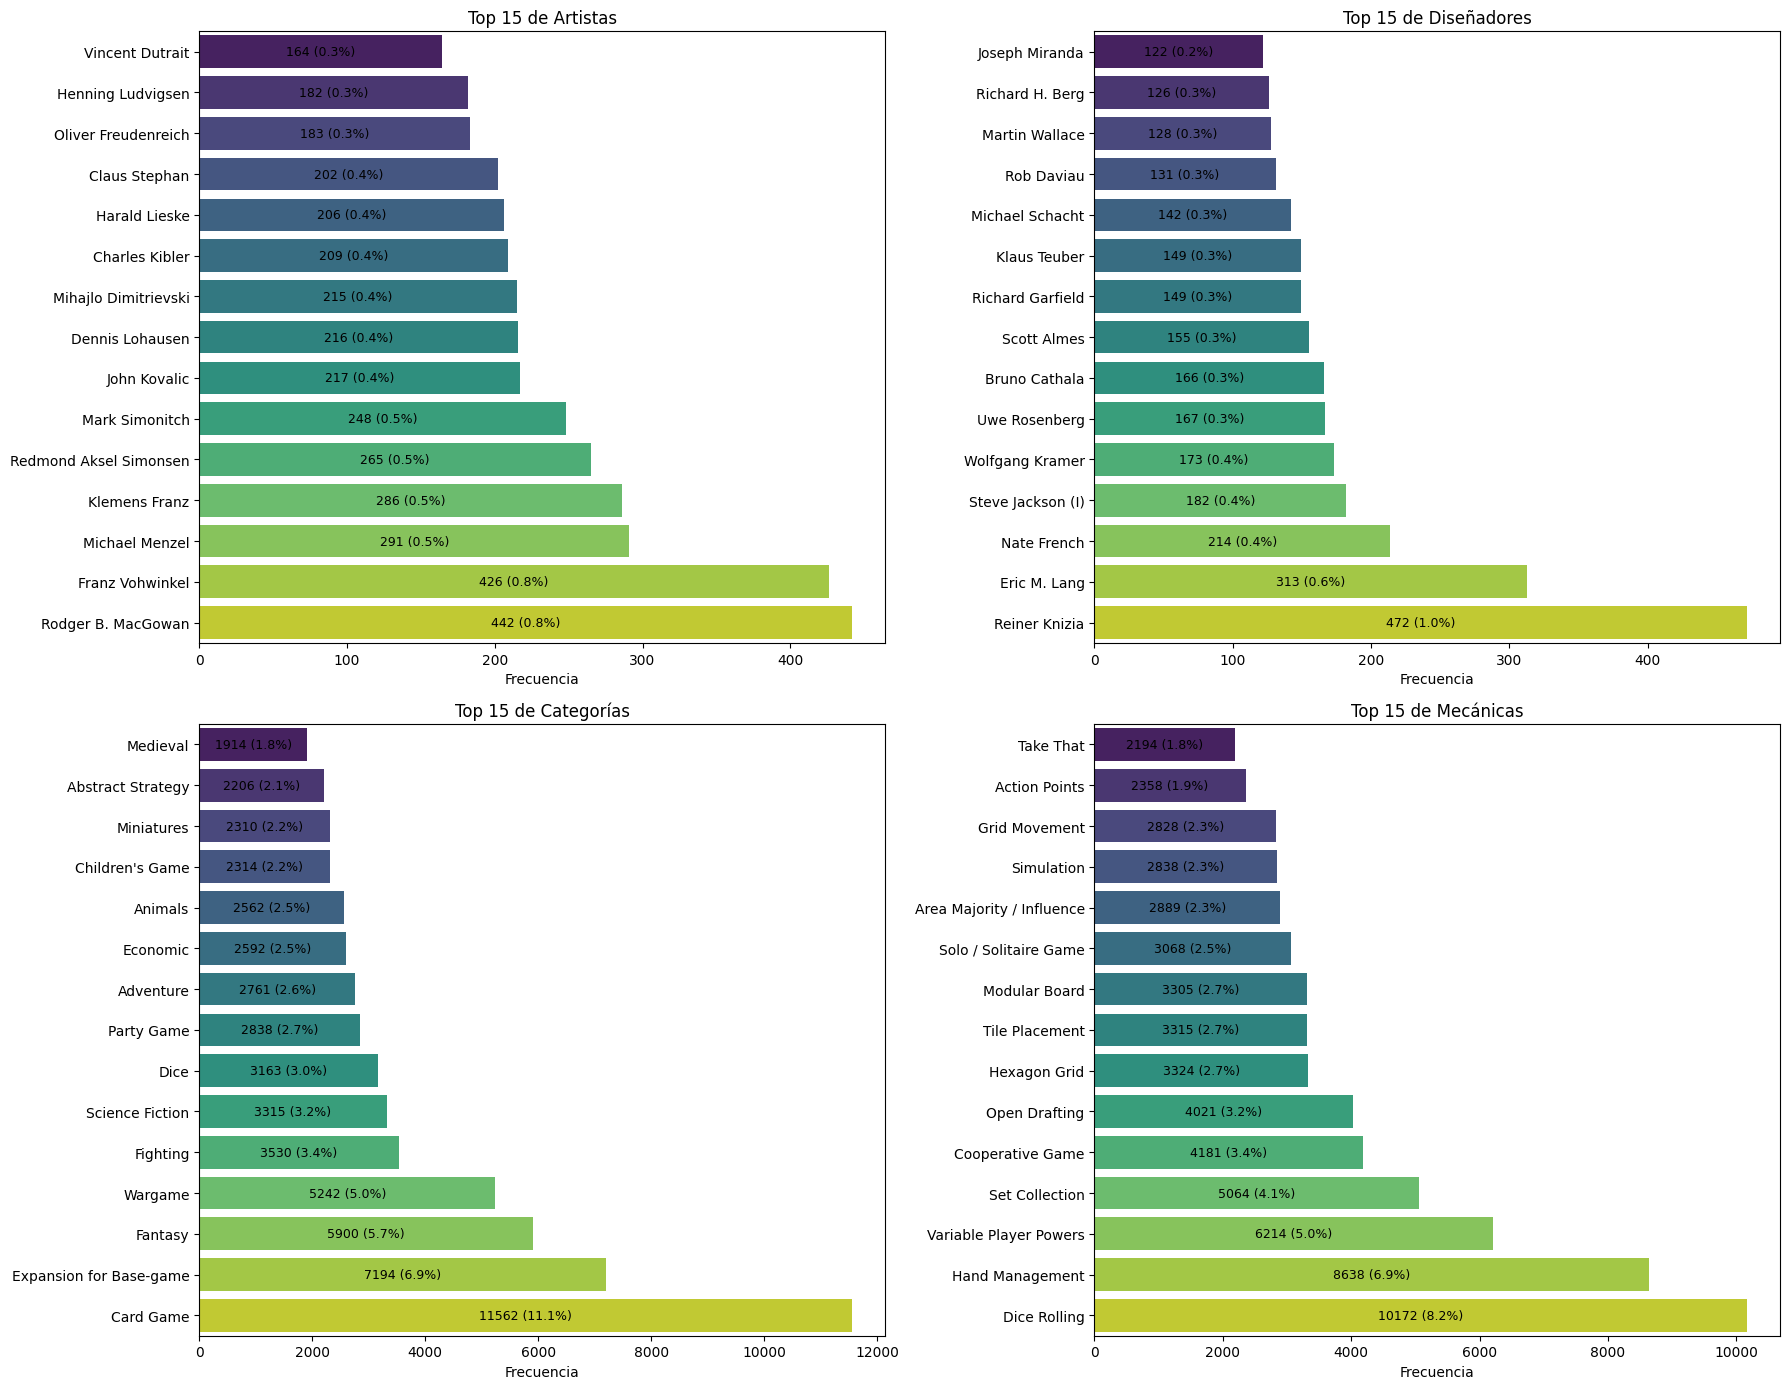

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

tablas = {
    'Artistas': artistas['artists'],
    'Diseñadores': disenyadores['designers'],
    'Categorías': categorias['categories'],
    'Mecánicas': mecanicas['mechanisms']
}

items = list(tablas.items())[:len(axes)]

for ax, (titulo, serie) in zip(axes, items):
    serie = serie.dropna().astype(str)
    total = serie.shape[0]
    top15 = serie.value_counts().head(15).sort_values()
    colors = sns.color_palette("viridis", n_colors=len(top15))
    sns.barplot(x=top15.values, y=top15.index, hue=top15.index, palette=colors, ax=ax)
    ax.set_title(f"Top 15 de {titulo}")
    ax.set_xlabel("Frecuencia")
    ax.set_ylabel("")

    max_width = top15.values.max() if len(top15) > 0 else 0
    for p in ax.patches:
        width = p.get_width()
        count = int(width)
        pct = width / total * 100 if total > 0 else 0
        if max_width > 0 and width >= max_width * 0.15:
            x = width / 2
            ha = "center"
        else:
            x = width + (max_width * 0.01 if max_width > 0 else 0.01)
            ha = "left"
        ax.text(x, p.get_y() + p.get_height() / 2, f"{count} ({pct:.1f}%)", ha=ha, va="center", color="black", fontsize=9)

plt.tight_layout()
plt.show()

In [17]:
disenyadores_mecanicas = pd.merge(disenyadores, mecanicas, on='row_id')
disenyadores_mecanicas.head()

,row_id,designers,mechanisms
0,224517,Gavan Brown,Chaining
1,224517,Gavan Brown,End Game Bonuses
2,224517,Gavan Brown,Hand Management
3,224517,Gavan Brown,Income
4,224517,Gavan Brown,Loans


In [18]:
# Total de apariciones de cada mecánica
total_mecanica = (
    disenyadores_mecanicas
    .groupby('mechanisms')
    .size()
    .reset_index(name='total_apariciones')
)

# Autor más frecuente en cada mecánica
autor_por_mecanica = (
    disenyadores_mecanicas
    .groupby(['mechanisms', 'designers'])['row_id']
    .nunique()
    .reset_index(name='veces')
    .sort_values(['mechanisms', 'veces'], ascending=[True, False])
    .drop_duplicates(subset='mechanisms', keep='first')
)

# Unir y ordenar por el total de apariciones de la mecánica
autor_por_mecanica = (
    autor_por_mecanica
    .merge(total_mecanica, on='mechanisms', how='left')
    .sort_values('total_apariciones', ascending=False)
).reset_index(drop=True)

print("Top 15 mecánicas con su autor más frecuente y total de apariciones:")
print(autor_por_mecanica.head(15))


Top 15 mecánicas con su autor más frecuente y total de apariciones:
                   mechanisms           designers  veces  total_apariciones
0                Dice Rolling   Steve Jackson (I)    135              15204
1             Hand Management         Nate French    203              12512
2      Variable Player Powers         Nate French    165              10521
3            Cooperative Game         Nate French    117               7023
4              Set Collection       Reiner Knizia    129               6635
5               Open Drafting        Eric M. Lang    111               5760
6               Modular Board        Richard Borg     54               5141
7                Hexagon Grid     Richard H. Berg    109               4909
8       Solo / Solitaire Game         Scott Almes     60               4553
9              Tile Placement  Klaus-Jürgen Wrede     80               4443
10              Grid Movement         Colby Dauch     58               4146
11  Area Majority / 

In [19]:
bgg_games['rank_boardgame'] = pd.to_numeric(bgg_games['rank_boardgame'], errors='coerce')
top100_bgg_games = bgg_games[bgg_games['rank_boardgame']!= 'Not Ranked'].sort_values('rank_boardgame', ascending=True).head(100)
top100_bgg_games

,row_id,type,name,min_players,max_players,playingtime,minimum_age,release_year,average_rating,num_of_ratings,weight,num_of_weights,bayes_average,std_deviation,language_dependency,owned,trading,wanting,wishing,rank_boardgame
0,224517,boardgame,Brass: Birmingham,2,4,120,14,2018,8.56433,58318,3.8607,2850,8.39353,1.42790,1: No necessary in-game text,83744,367,1754,21874,1.0
10208,342942,boardgame,Ark Nova,1,4,150,14,2021,8.54058,60867,3.7963,3118,8.35456,1.40476,4: Extensive use of text - massive conversion ...,88580,447,1071,17713,2.0
19801,161936,boardgame,Pandemic Legacy: Season 1,2,4,60,13,2015,8.50255,57354,2.8278,1556,8.34628,1.60876,4: Extensive use of text - massive conversion ...,89321,524,807,15019,3.0
21431,174430,boardgame,Gloomhaven,1,4,120,14,2017,8.53957,67111,3.9187,2755,8.29747,1.73643,4: Extensive use of text - massive conversion ...,104470,1306,1158,22286,4.0
22517,397598,boardgame,Dune: Imperium – Uprising,1,6,120,13,2023,8.70003,18269,3.5243,576,8.23575,1.33245,3: Moderate in-game text - needs crib sheet or...,28205,82,886,7794,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27490,157354,boardgame,Five Tribes: The Djinns of Naqala,2,4,80,13,2014,7.76431,45190,2.8389,1633,7.60804,1.26778,1: No necessary in-game text,59773,568,1259,11607,96.0
27596,277659,boardgame,Final Girl,1,1,60,14,2021,8.22407,11198,2.7553,282,7.60724,1.40274,3: Moderate in-game text - needs crib sheet or...,28067,266,344,4532,97.0
27703,230802,boardgame,Azul,2,4,45,8,2017,7.71518,108193,1.7743,2915,7.60569,1.16819,1: No necessary in-game text,183232,1077,945,16199,98.0
27808,413246,boardgame,Bomb Busters,2,5,30,10,2024,8.03710,12838,1.9971,347,7.60305,1.24457,3: Moderate in-game text - needs crib sheet or...,25659,82,655,6656,99.0


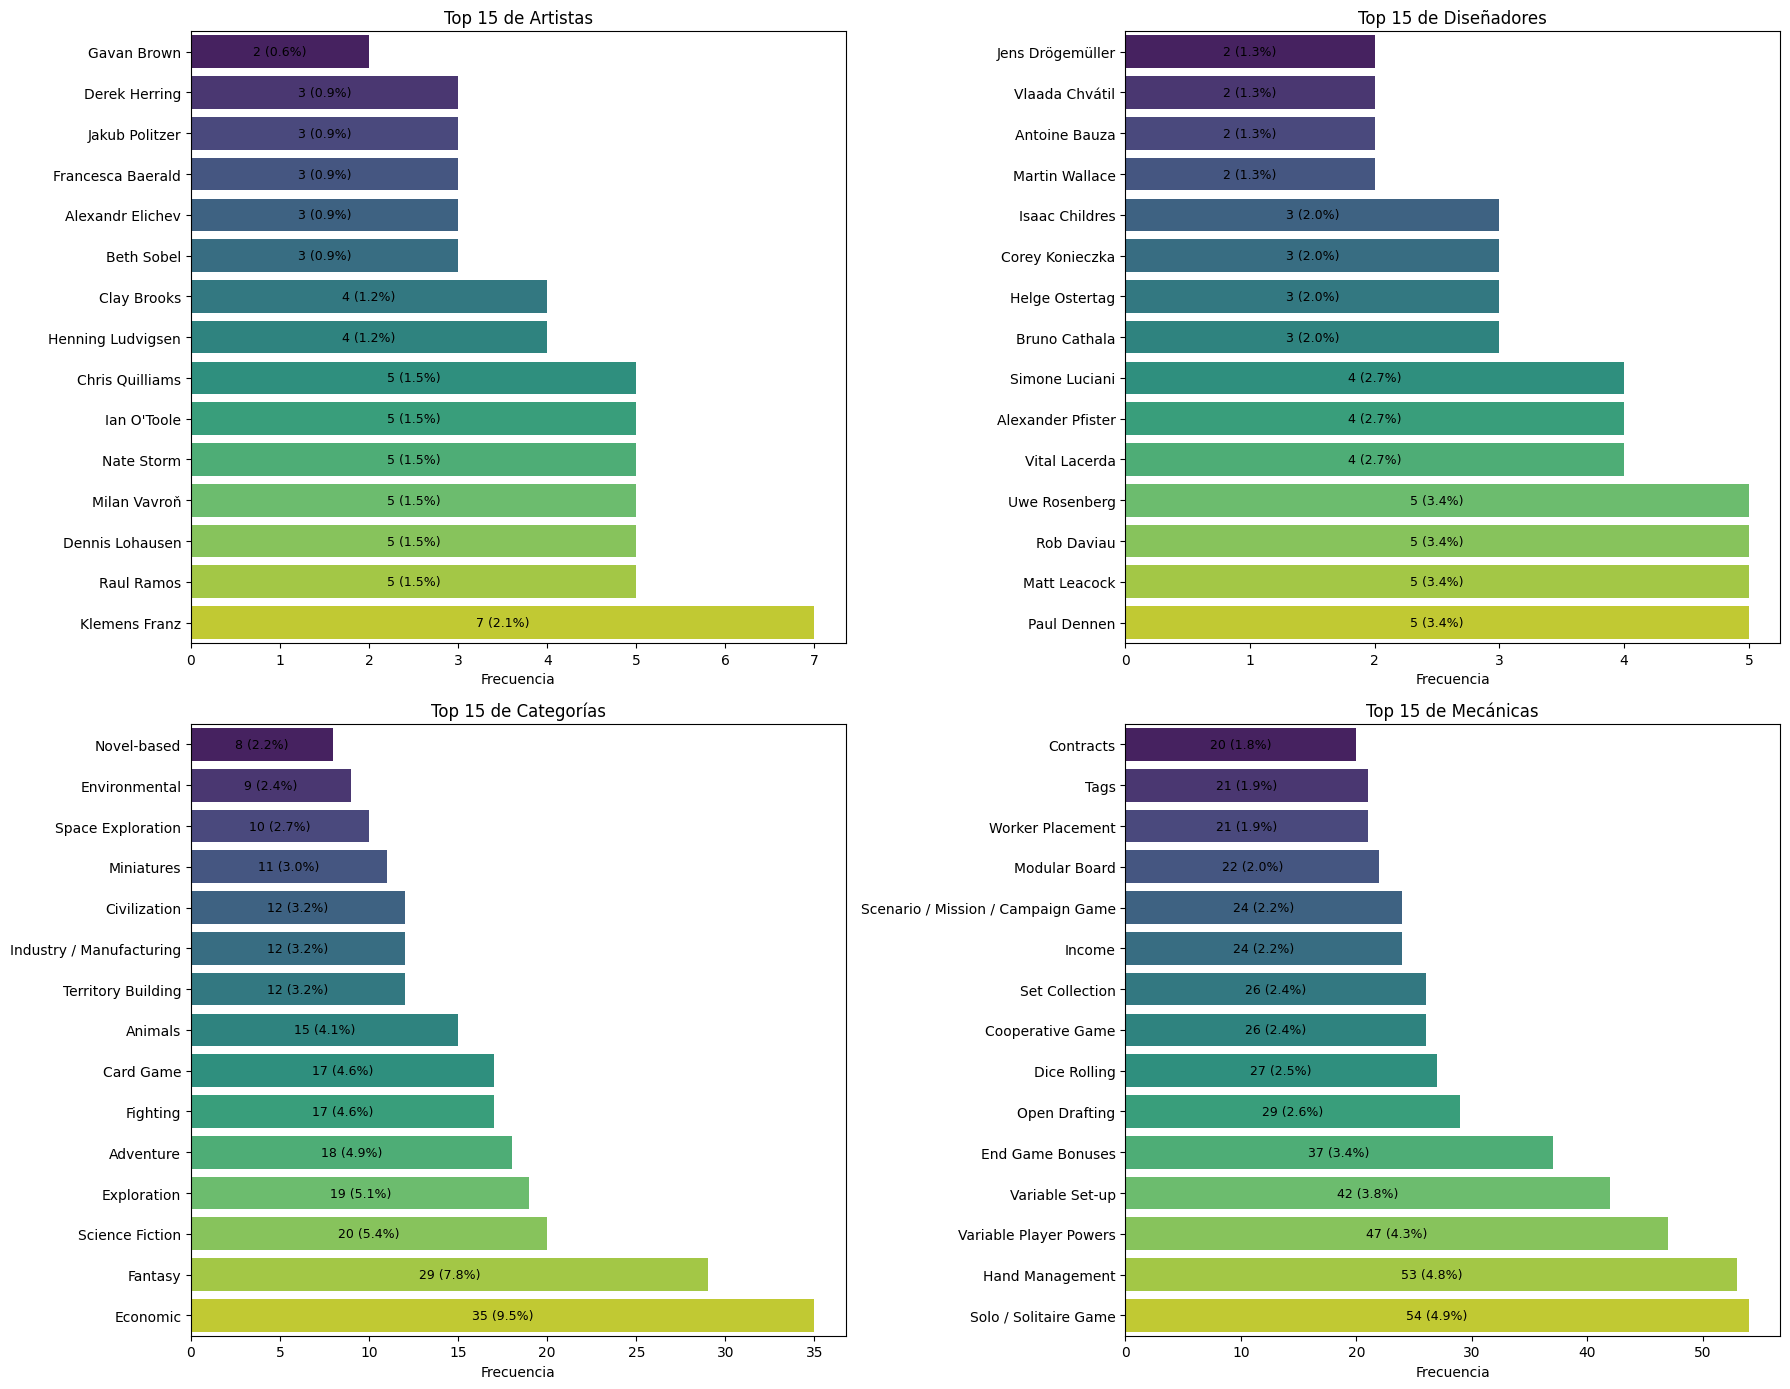

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

artistas_top100 = artistas[artistas['row_id'].isin(top100_bgg_games['row_id'])]
disenyadores_top100 = disenyadores[disenyadores['row_id'].isin(top100_bgg_games['row_id'])]
categorias_top100 = categorias[categorias['row_id'].isin(top100_bgg_games['row_id'])]
mecanicas_top100 = mecanicas[mecanicas['row_id'].isin(top100_bgg_games['row_id'])]


tablas = {
    'Artistas': artistas_top100['artists'],
    'Diseñadores': disenyadores_top100['designers'],
    'Categorías': categorias_top100['categories'],
    'Mecánicas': mecanicas_top100['mechanisms']
}

items = list(tablas.items())[:len(axes)]

for ax, (titulo, serie) in zip(axes, items):
    serie = serie.dropna().astype(str)
    total = serie.shape[0]
    top15 = serie.value_counts().head(15).sort_values()
    colors = sns.color_palette("viridis", n_colors=len(top15))
    sns.barplot(x=top15.values, y=top15.index, hue=top15.index, palette=colors, ax=ax)
    ax.set_title(f"Top 15 de {titulo}")
    ax.set_xlabel("Frecuencia")
    ax.set_ylabel("")

    max_width = top15.values.max() if len(top15) > 0 else 0
    for p in ax.patches:
        width = p.get_width()
        count = int(width)
        pct = width / total * 100 if total > 0 else 0
        if max_width > 0 and width >= max_width * 0.15:
            x = width / 2
            ha = "center"
        else:
            x = width + (max_width * 0.01 if max_width > 0 else 0.01)
            ha = "left"
        ax.text(x, p.get_y() + p.get_height() / 2, f"{count} ({pct:.1f}%)", ha=ha, va="center", color="black", fontsize=9)

plt.tight_layout()
plt.show()

In [21]:
bgg_games['interest'] = bgg_games['owned'] + bgg_games['wishing']
interest_sorted = bgg_games.sort_values('interest', ascending=False).head(100)
interest_sorted.head(20)

,row_id,type,name,min_players,max_players,playingtime,minimum_age,release_year,average_rating,num_of_ratings,...,num_of_weights,bayes_average,std_deviation,language_dependency,owned,trading,wanting,wishing,rank_boardgame,interest
23778,13,boardgame,Catan,3,4,120,10,1995,7.09086,142100,...,8561,6.90388,1.50648,2: Some necessary text - easily memorized or s...,239917,2358,522,8195,616.0,248112
7392,30549,boardgame,Pandemic,2,4,45,8,2008,7.51349,134988,...,6297,7.40404,1.33943,2: Some necessary text - easily memorized or s...,225741,3351,611,11827,171.0,237568
13842,822,boardgame,Carcassonne,2,5,45,7,2000,7.41627,139626,...,8634,7.29882,1.31206,1: No necessary in-game text,223196,2072,710,11051,238.0,234247
21212,266192,boardgame,Wingspan,1,5,70,10,2019,7.99930,112700,...,3736,7.84618,1.37484,4: Extensive use of text - massive conversion ...,180248,941,1261,21934,38.0,202182
27703,230802,boardgame,Azul,2,4,45,8,2017,7.71518,108193,...,2915,7.60569,1.16819,1: No necessary in-game text,183232,1077,945,16199,98.0,199431
14035,173346,boardgame,7 Wonders Duel,2,2,30,10,2015,8.07720,108741,...,3420,7.95241,1.20211,1: No necessary in-game text,183970,1435,855,12214,24.0,196184
6499,178900,boardgame,Codenames,2,8,15,10,2015,7.52488,103867,...,2577,7.42835,1.30206,5: Unplayable in another language,179972,1485,361,7918,162.0,187890
26837,167791,boardgame,Terraforming Mars,1,5,120,12,2016,8.33804,113026,...,4648,8.18708,1.43051,4: Extensive use of text - massive conversion ...,159431,839,1864,27010,9.0,186441
1814,68448,boardgame,7 Wonders,2,7,30,10,2010,7.66257,112612,...,5531,7.54885,1.27731,1: No necessary in-game text,155765,1992,953,15004,117.0,170769
15799,9209,boardgame,Ticket to Ride,2,5,60,8,2004,7.38569,98290,...,5225,7.26122,1.30273,1: No necessary in-game text,148824,1208,686,8683,259.0,157507


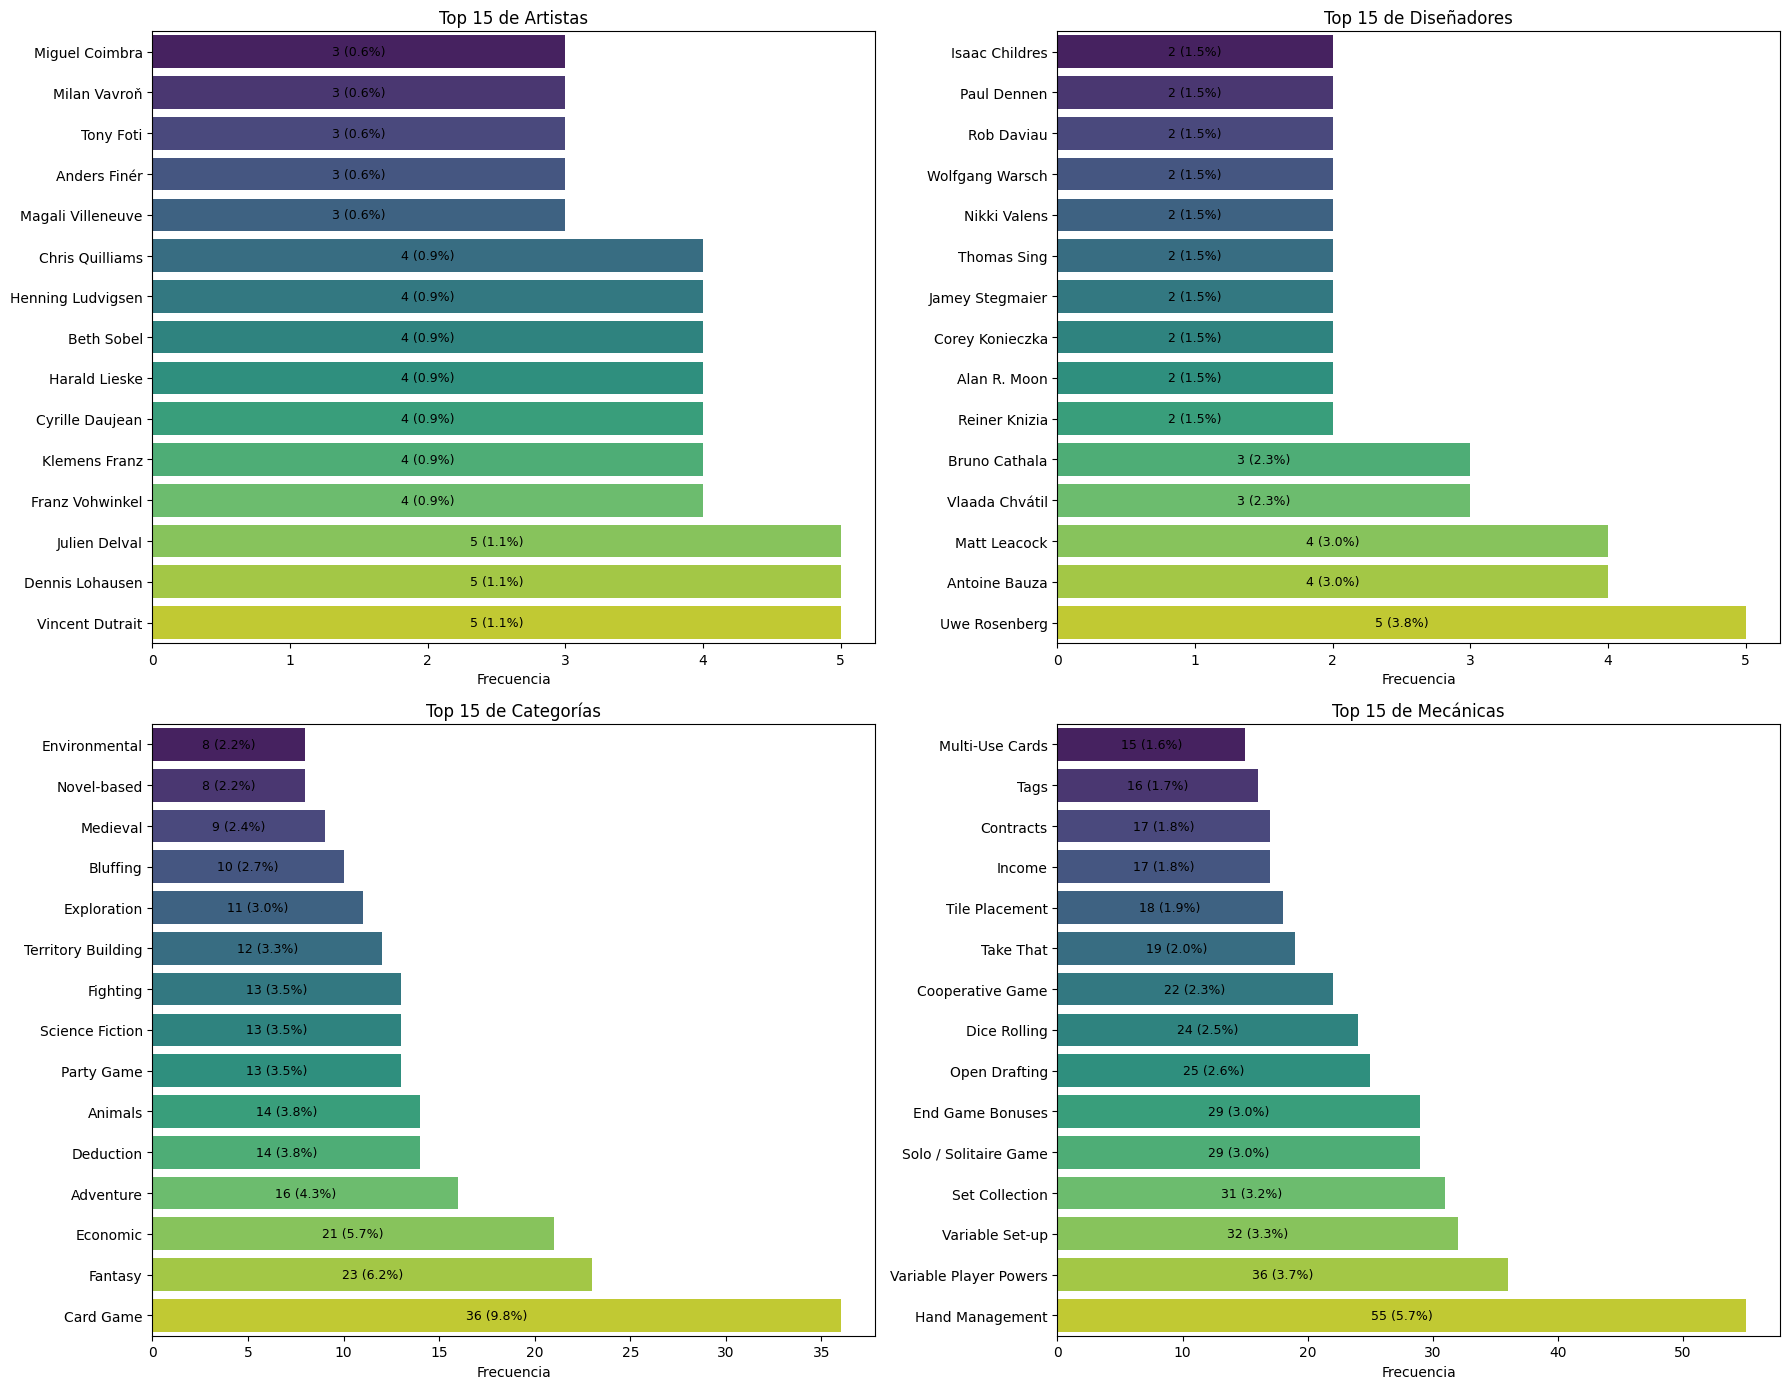

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

artistas_interest = artistas[artistas['row_id'].isin(interest_sorted['row_id'])]
disenyadores_interest = disenyadores[disenyadores['row_id'].isin(interest_sorted['row_id'])]
categorias_interest = categorias[categorias['row_id'].isin(interest_sorted['row_id'])]
mecanicas_interest = mecanicas[mecanicas['row_id'].isin(interest_sorted['row_id'])]


tablas = {
    'Artistas': artistas_interest['artists'],
    'Diseñadores': disenyadores_interest['designers'],
    'Categorías': categorias_interest['categories'],
    'Mecánicas': mecanicas_interest['mechanisms']
}

items = list(tablas.items())[:len(axes)]

for ax, (titulo, serie) in zip(axes, items):
    serie = serie.dropna().astype(str)
    total = serie.shape[0]
    top15 = serie.value_counts().head(15).sort_values()
    colors = sns.color_palette("viridis", n_colors=len(top15))
    sns.barplot(x=top15.values, y=top15.index, hue=top15.index, palette=colors, ax=ax)
    ax.set_title(f"Top 15 de {titulo}")
    ax.set_xlabel("Frecuencia")
    ax.set_ylabel("")

    max_width = top15.values.max() if len(top15) > 0 else 0
    for p in ax.patches:
        width = p.get_width()
        count = int(width)
        pct = width / total * 100 if total > 0 else 0
        if max_width > 0 and width >= max_width * 0.15:
            x = width / 2
            ha = "center"
        else:
            x = width + (max_width * 0.01 if max_width > 0 else 0.01)
            ha = "left"
        ax.text(x, p.get_y() + p.get_height() / 2, f"{count} ({pct:.1f}%)", ha=ha, va="center", color="black", fontsize=9)

plt.tight_layout()
plt.show()